# Best Camera Model, Round 2 — Held-Out Generalization

Round 1's evaluation had a blind spot: every eval track was a
*reinvent-route variant* — same circuit geometry, different looks and
widths. This round trains a fresh model on genuinely different circuits
and holds out **4 more it never sees**, chosen to span the track library's
geometry space (18–42 m, gentle ovals to technical layouts, including the
Bowtie crossover topology).

Because the round-1 winner did not transfer to diverse track mixes as-is
(one run converged to a stand-still local optimum, another stayed flat),
this round runs its own HPO **on the diverse task itself**, with
`entropy_coef` searched wider and `dr` itself searchable. This notebook is
where the **takeoff lottery** was first characterized: identical config +
seed can park or fly on GPU nondeterminism alone.

Cells run in-process; step results record under
`runs/best_camera_diverse/logs/` (`REUSE = True` replays them). Honest
caveat: the sim's episode timeout is a fixed 30 s, so an L-metre lap needs
≥ L/30 m/s — mean progress is the timeout-free comparison signal.


In [1]:
# --- configuration (papermill parameters cell) ------------------------------
SEED = 0
ROOT = "runs/best_camera_diverse"
WALL_BUDGET_H = 8.0
TRAIN_RESERVE_H = 0.7
REUSE = False                      # replay recorded step results

TRAIN_TRACKS = ("reinvent_base", "Oval_track", "Mexico_track", "China_track",
                "reInvent2019_track", "2022_summit_speedway", "caecer_loop")
HOLDOUT_TRACKS = ("Bowtie_track", "New_York_Track", "thunder_hill_open",
                  "arctic_open")

# round-1 HPO winner (runs/best_camera/study.db, trial 001)
BEST = {"lr": 1.5529021289627495e-4, "entropy_coef": 3.68356162276608e-3,
        "epochs": 5, "minibatches": 4, "frame_stack": 1, "gamma": 0.995}

NUM_ENVS = 128
RESOLUTION = (160, 120)
BENCH_STEPS = 150

# HPO on the diverse task itself
HPO_TRIALS = 14
HPO_DEADLINE_H = 4.2
TRIAL_STEPS = 2_400_000
TRIAL_EVAL_EVERY = 1_200_000

FINAL_STEPS_MAX = 26_000_000
FINAL_STEPS_MIN = 2_000_000
FINAL_EVALS = 6
TRAIN_SPS_EST = 2500               # conservative training-rate estimate


In [2]:
# Parameters
REUSE = True


In [3]:
"""Session helpers: result caching, figure display, budget clock.

Everything runs **in this process** — genesis rebuilds scenes fine within
one process (the hpo example relies on it), and a dead training draw is
stopped by raising out of ``run(on_eval=...)`` rather than killing a child
process. Each named step's result is recorded as JSON under
``<ROOT>/logs``; with ``REUSE = True`` an existing result is returned
instead of recomputed, so a finished notebook re-executes in minutes
without retraining — and if a hard GPU fault ever kills the kernel (e.g.
VRAM exhausted by another process), restarting with ``REUSE = True``
resumes from the last recorded step instead of from scratch. The one exception is the ONNX export, which must run
in a genesis-free process (LLVM symbol clash) — it stays a single CLI
subprocess at the end.
"""

import io
import json
import os
import time

from IPython.display import Image, display

from deepracer_genesis.experiment import run

# survive a shared GPU: cap Madrona's device heap (its default does not fit
# next to a resident LLM server) and let torch grow segments on demand
os.environ.setdefault("MADRONA_MWGPU_DEVICE_HEAP_SIZE", str(1 << 30))
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

T0 = time.time()
LOGS = os.path.join(ROOT, "logs")
os.makedirs(LOGS, exist_ok=True)


def elapsed_h() -> float:
    """Wall-clock hours since the notebook started."""
    return (time.time() - T0) / 3600.0


def recorded(name: str):
    """Return a step's recorded result when REUSE is on and it exists."""
    path = os.path.join(LOGS, f"{name}.result.json")
    if REUSE and os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None


def record_result(name: str, result: dict) -> dict:
    """Write a step's result JSON and return it."""
    with open(os.path.join(LOGS, f"{name}.result.json"), "w") as f:
        json.dump(result, f)
    return result


def cached_run(name: str, spec, on_eval=None) -> dict:
    """Train ``spec`` (or return the step's recorded result).

    Args:
        name: Step name — keys the result JSON under ``LOGS``.
        spec: The built ExperimentSpec to train.
        on_eval: Optional periodic-eval callback; raising inside it stops
            the run (the takeoff guard and HPO pruning both use this).

    Returns:
        ``{"metrics", "history", "holdout", "train", "run_dir"}``.
    """
    result = recorded(name)
    if result is not None:
        return result
    rec = run(spec, root=ROOT, on_eval=on_eval)
    return record_result(name, {
        "metrics": rec.metrics, "history": rec.eval_history,
        "holdout": rec.holdout, "train": rec.train,
        "run_dir": spec.run_dir(ROOT)})


def show_fig(fig) -> None:
    """Render a figure inline regardless of the active matplotlib backend.

    ``analysis.trackplots`` forces Agg, under which plain ``plt.show()``
    renders nothing in a notebook.

    Args:
        fig: The matplotlib figure.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(buf.getvalue()))

def bench(name: str, spec, steps: int = BENCH_STEPS) -> dict:
    """Measure a spec's rollout throughput (cached by step name).

    Rollout-only — PPO training runs several times slower; only the ratio
    between configs transfers.

    Args:
        name: Step name for the result cache.
        spec: The built spec to bench.
        steps: Timed control steps.

    Returns:
        ``{"env_steps_per_s": float}`` (or ``{"error": ...}``).
    """
    result = recorded(name)
    if result is not None:
        return result
    import torch

    from deepracer_genesis.experiment.builder import Builder
    from deepracer_genesis.experiment.evaluator import evaluate_policy

    try:
        sim = Builder(spec).sim()
        actor_action = torch.zeros(sim.num_envs, 2, device=sim.device)
        actor_action[:, 1] = 0.4

        def actor(td):
            td.set("action", actor_action)
            return td

        with torch.inference_mode():
            evaluate_policy(sim, actor, steps=30)          # warmup / JIT
            t0 = time.perf_counter()
            evaluate_policy(sim, actor, steps=steps)
            dt = time.perf_counter() - t0
        result = {"env_steps_per_s": round(steps * sim.num_envs / dt, 1)}
    except Exception as e:                    # noqa: BLE001 - table shows it
        result = {"error": f"{type(e).__name__}: {e}"}
    return record_result(name, result)


In [4]:
"""Spec building for the diverse task."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deepracer_genesis.experiment import (
    AsymmetricCameraPolicy, CameraEnvironment, DomainRandomizationActions,
    DomainRandomizationCamera, DomainRandomizationPhysics,
    DomainRandomizationTrackAppearance, Evaluation, PPO)


def diverse_spec(*, dr=True, real_tracks=(), steps=TRIAL_STEPS,
                 eval_every=TRIAL_EVAL_EVERY, variant="final",
                 lr=BEST["lr"], entropy_coef=BEST["entropy_coef"],
                 epochs=BEST["epochs"], minibatches=BEST["minibatches"],
                 frame_stack=BEST["frame_stack"], gamma=BEST["gamma"]):
    """Build one diverse-task camera spec (full DR by default).

    Args:
        dr: Apply the full DR stack.
        real_tracks: Per-track no-DR holdout eval after training.
        steps: Total env-steps.
        eval_every: Periodic-eval cadence.
        variant: Run-dir variant name.
        lr: PPO learning rate.
        entropy_coef: PPO entropy bonus.
        epochs: PPO epochs per iteration.
        minibatches: PPO minibatches per epoch.
        frame_stack: Frames stacked along channels.
        gamma: Reward discount.

    Returns:
        The validated frozen spec.
    """
    pipe = CameraEnvironment(render="madrona", resolution=RESOLUTION,
                             num_envs=NUM_ENVS, tracks=TRAIN_TRACKS,
                             frame_stack=frame_stack, random_direction=True)
    if dr:
        pipe = (pipe
                >> DomainRandomizationTrackAppearance(strength=0.6)
                >> DomainRandomizationCamera(brightness=(0.7, 1.3), hue=0.05,
                                             blur=0.3, camera_jitter=True)
                >> DomainRandomizationPhysics())
    pipe = pipe >> AsymmetricCameraPolicy(
        actor_keys=("camera",), critic_keys=("camera", "state"),
        distribution={"std_range": (0.1, 1.0)})
    if dr:
        pipe = pipe >> DomainRandomizationActions(
            steer_noise=0.02, speed_noise=0.05, delay_steps=1)
    pipe = pipe >> PPO(lr=lr, entropy_coef=entropy_coef, epochs=epochs,
                       minibatches=minibatches, gamma=gamma)
    if real_tracks:
        pipe = pipe >> Evaluation(real_tracks=tuple(real_tracks), charts=True)
    return pipe.build(seed=SEED, total_env_steps=steps,
                      eval_every_steps=eval_every,
                      group="best_camera_diverse", variant=variant)


print(f"root={ROOT} train={len(TRAIN_TRACKS)} holdout={len(HOLDOUT_TRACKS)} "
      f"reuse={REUSE}")


root=runs/best_camera_diverse train=7 holdout=4 reuse=True


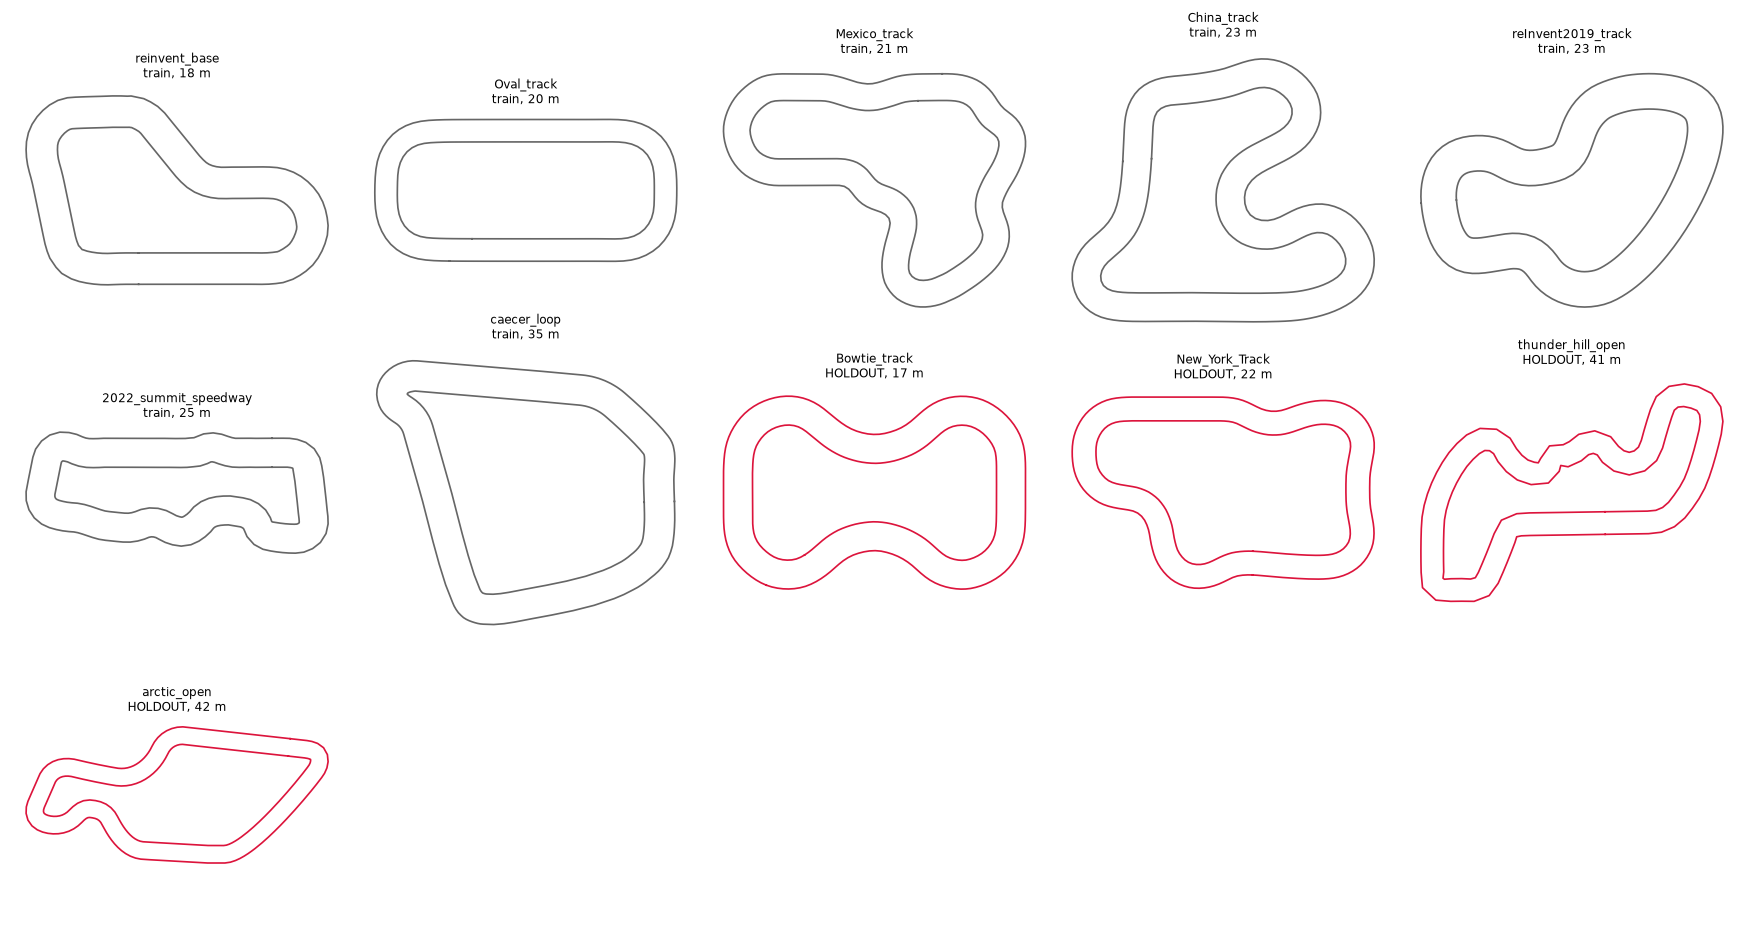

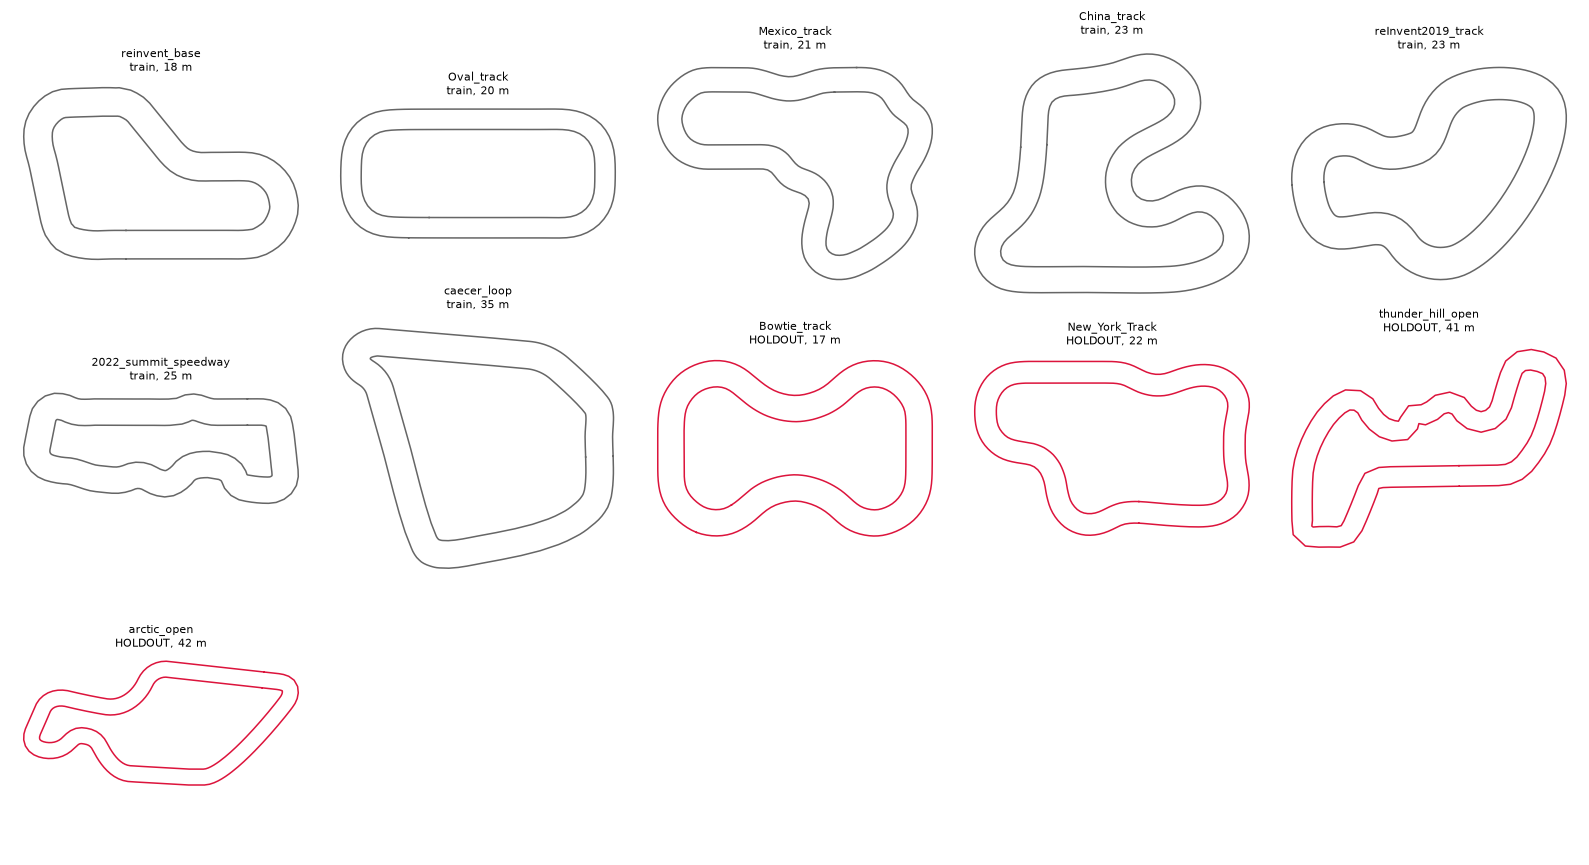

In [5]:
"""The geometry space: train vs holdout circuits at a glance."""

from deepracer_genesis import tracks as track_catalog

ALL = ([(n, "train") for n in TRAIN_TRACKS]
       + [(n, "HOLDOUT") for n in HOLDOUT_TRACKS])
cols = 5
rows = -(-len(ALL) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 2.9 * rows))
for ax in axes.flat[len(ALL):]:
    ax.axis("off")
for (name, kind), ax in zip(ALL, axes.flat):
    route = np.load(track_catalog.info(name).route_path)
    for sl in (slice(2, 4), slice(4, 6)):
        border = np.vstack([route[:, sl], route[:1, sl]])
        ax.plot(border[:, 0], border[:, 1], lw=1.1,
                color="crimson" if kind == "HOLDOUT" else "0.4")
    seg = np.diff(np.vstack([route[:, :2], route[:1, :2]]), axis=0)
    length = np.linalg.norm(seg, axis=1).sum()
    ax.set_title(f"{name}\n{kind}, {length:.0f} m", fontsize=8)
    ax.set_aspect("equal")
    ax.axis("off")
fig.tight_layout()
show_fig(fig)


## HPO on the diverse task

The search runs on the actual target: the diverse train tracks with the
full stack. `entropy_coef` is searched up to 2e-2 and `dr` itself is a
searchable flag. The anchors are the round-1 winner with and without DR —
and the with-DR anchor was this study's only takeoff, so DR is not the
blocker some failures suggested.


In [6]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial: optuna.Trial) -> float:
    """Train one short diverse-task config and score its final eval.

    Args:
        trial: The Optuna trial supplying hyperparameters.

    Returns:
        ``mean_progress_m`` of the final deterministic eval.
    """
    spec = diverse_spec(
        lr=trial.suggest_float("lr", 3e-5, 6e-4, log=True),
        entropy_coef=trial.suggest_float("entropy_coef", 3e-4, 2e-2, log=True),
        epochs=trial.suggest_int("epochs", 3, 6),
        minibatches=trial.suggest_categorical("minibatches", [4, 8]),
        frame_stack=trial.suggest_categorical("frame_stack", [1, 4]),
        gamma=trial.suggest_categorical("gamma", [0.99, 0.995]),
        dr=trial.suggest_categorical("dr", [True, False]),
        variant=f"t{trial.number:03d}")
    m = cached_run(f"trial_{trial.number:03d}", spec)["metrics"]
    print(f"  trial {trial.number}: progress={m['mean_progress_m']:.2f}m "
          f"completion={m['completion_rate']:.2f}")
    return float(m["mean_progress_m"])


study = optuna.create_study(
    direction="maximize", study_name="best_camera_diverse",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=f"sqlite:///{ROOT}/study.db", load_if_exists=True)
if not study.trials:
    for dr in (True, False):               # anchors: round-1 winner +/- DR
        study.enqueue_trial({**BEST, "dr": dr})

while (sum(t.state.is_finished() for t in study.trials) < HPO_TRIALS
       and elapsed_h() < HPO_DEADLINE_H):
    study.optimize(objective, n_trials=1)

display(pd.DataFrame([
    {"trial": t.number, "state": t.state.name, "progress_m": t.value,
     **t.params}
    for t in study.trials]).sort_values("progress_m", ascending=False).head(15))
HPO_BEST = dict(study.best_params)
print("winner:", HPO_BEST, "->", round(study.best_value, 2), "m")


,trial,state,progress_m,lr,entropy_coef,epochs,minibatches,frame_stack,gamma,dr
0,0,COMPLETE,10.830147,0.000155,0.003684,5,4,1,0.995,True
5,5,COMPLETE,2.943995,0.000165,0.000325,5,8,1,0.995,True
4,4,COMPLETE,1.850087,0.000120,0.007957,3,4,1,0.990,True
11,11,COMPLETE,1.820569,0.000081,0.000317,5,8,1,0.995,True
2,2,COMPLETE,1.817570,0.000155,0.006047,5,4,1,0.995,False
12,12,COMPLETE,1.787634,0.000274,0.001447,5,4,1,0.995,True
3,3,COMPLETE,1.779046,0.000146,0.003260,6,8,4,0.995,True
8,8,COMPLETE,1.761483,0.000351,0.000451,6,8,4,0.995,False
6,6,COMPLETE,1.750922,0.000221,0.005015,3,8,4,0.995,False
10,10,COMPLETE,1.646025,0.000502,0.017971,4,4,1,0.990,True


winner: {'lr': 0.00015529021289627495, 'entropy_coef': 0.00368356162276608, 'epochs': 5, 'minibatches': 4, 'frame_stack': 1, 'gamma': 0.995, 'dr': True} -> 10.83 m


## Final training

The winner trains long on the diverse mix. Historical note: the first
final draw of this spec was flat and was killed by hand; the recorded run
is the successful redraw — the observation that became the automated
takeoff guard used in round 3.


In [7]:
r = bench("bench", diverse_spec(**HPO_BEST))
print("rollout bench:", r)

train_h = max(0.0, WALL_BUDGET_H - elapsed_h() - TRAIN_RESERVE_H)
FINAL_STEPS = int(min(FINAL_STEPS_MAX,
                      max(FINAL_STEPS_MIN, train_h * 3600 * TRAIN_SPS_EST)))
EVAL_EVERY = max(FINAL_STEPS // FINAL_EVALS, 500_000)
print(f"budget left {train_h:.2f}h -> FINAL_STEPS={FINAL_STEPS:,}")

final = cached_run("final", diverse_spec(
    real_tracks=HOLDOUT_TRACKS, steps=FINAL_STEPS, eval_every=EVAL_EVERY,
    variant="final", **HPO_BEST))
RUN_DIR = final["run_dir"]
print(f"run: {RUN_DIR}")
print("train:", final["train"])
print("DR-eval metrics:", {k: round(v, 3) for k, v in final["metrics"].items()
                           if isinstance(v, (int, float))})


rollout bench: {'env_steps_per_s': 8421.7}
budget left 7.30h -> FINAL_STEPS=26,000,000
run: runs/best_camera_diverse/best_camera_diverse/final-0-f25d6d245c08
train: {'wall_clock_s': 7685.8, 'total_env_steps': 22465536, 'steps_per_s': 2923.0, 'checkpoint': 'runs/best_camera_diverse/best_camera_diverse/final-0-f25d6d245c08/model.pt', 'backend': 'rsl_rl'}
DR-eval metrics: {'episodes': 469, 'mean_return': 155.817, 'mean_progress_m': 15.596, 'mean_episode_s': 7.882, 'completion_rate': 0.192, 'mean_laps': 0.685, 'offtrack_rate': 0.966, 'lap_time_s': 11.125, 'mean_speed_mps': 1.882}


<deepracer-genesis>/deepracer_genesis/experiment/spec.py:437: UserWarning: multi-track camera training uses Part O spatial tiling: all 7 track meshes load into every env (render + memory scale ~K); benchmark aggregate steps/sec before scaling the track count
  self._validate_obs_dr()


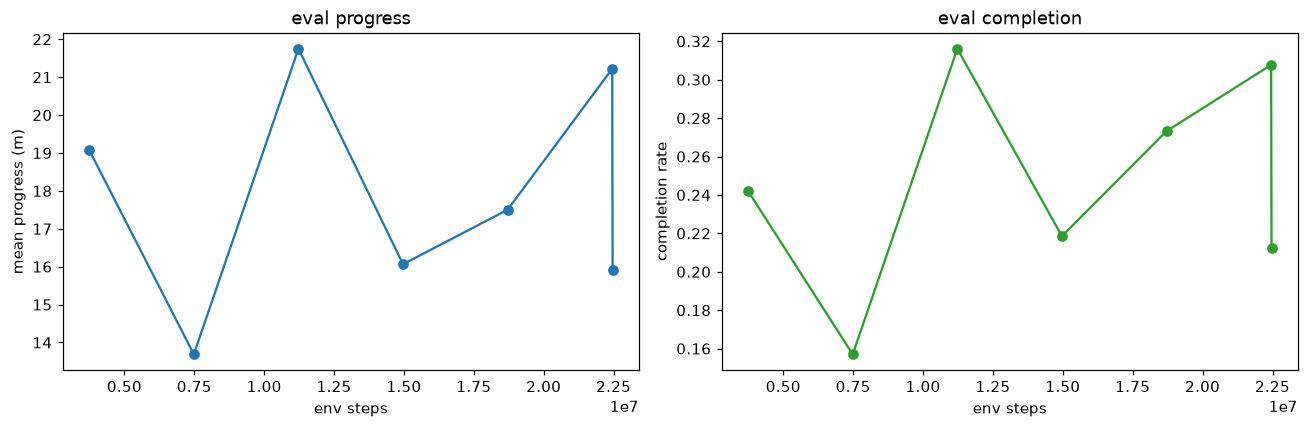

,mean_progress_m,completion_rate,offtrack_rate,mean_speed_mps,lap_time_s
Bowtie_track,19.488,0.349,0.908,1.626,9.541
New_York_Track,20.634,0.363,0.971,1.807,11.344
thunder_hill_open,24.398,0.099,0.981,2.072,17.531
arctic_open,21.853,0.050,0.995,2.157,17.014


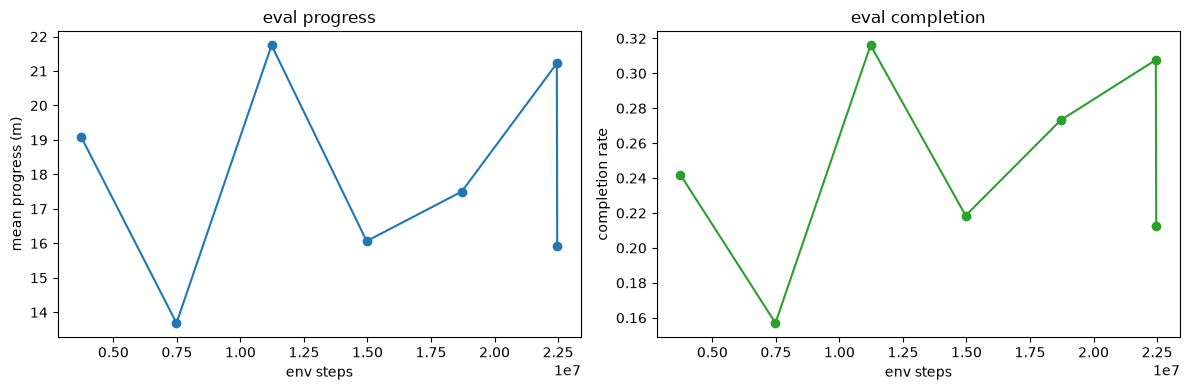

In [8]:
"""Learning curve + the headline: per-holdout-track results."""

hist = pd.DataFrame(final["history"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["frames"], hist["mean_progress_m"], marker="o")
ax[0].set(xlabel="env steps", ylabel="mean progress (m)", title="eval progress")
ax[1].plot(hist["frames"], hist["completion_rate"], marker="o", color="tab:green")
ax[1].set(xlabel="env steps", ylabel="completion rate", title="eval completion")
fig.tight_layout()
show_fig(fig)

display(pd.DataFrame(final["holdout"]).T[
    ["mean_progress_m", "completion_rate", "offtrack_rate",
     "mean_speed_mps", "lap_time_s"]].round(3))


Bowtie_track: 216 episodes, completion 36.6%, mean progress 18.7 m


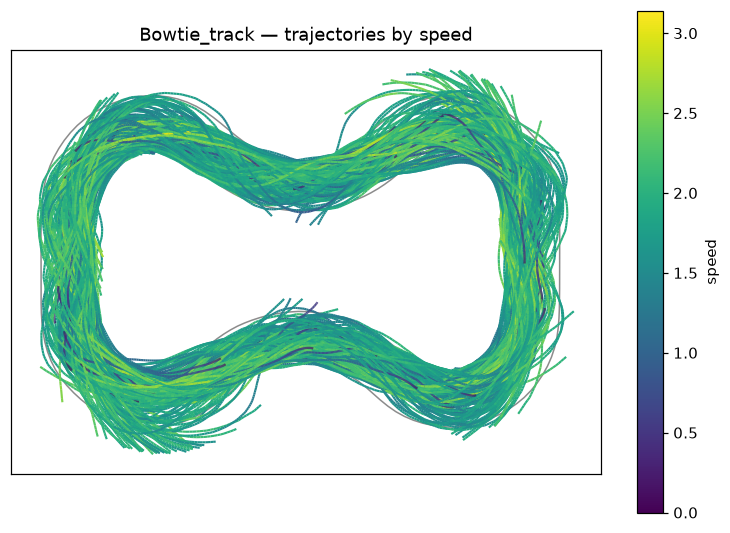

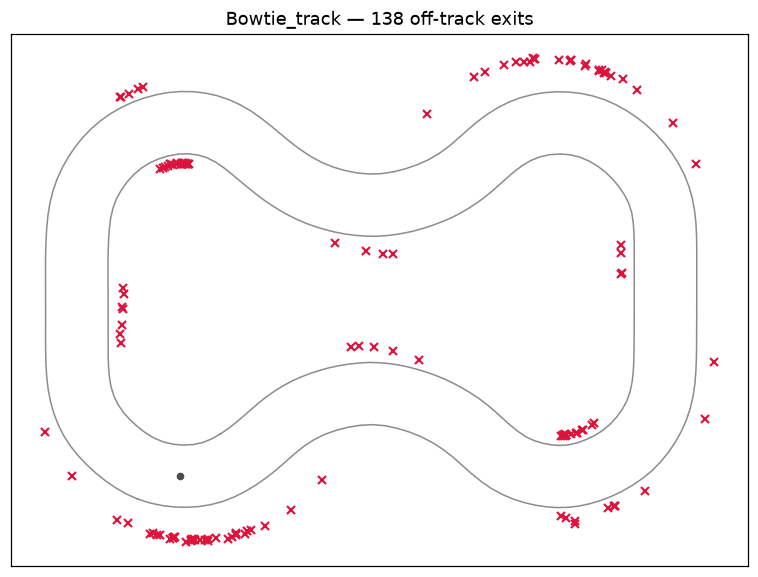

New_York_Track: 235 episodes, completion 29.8%, mean progress 17.9 m


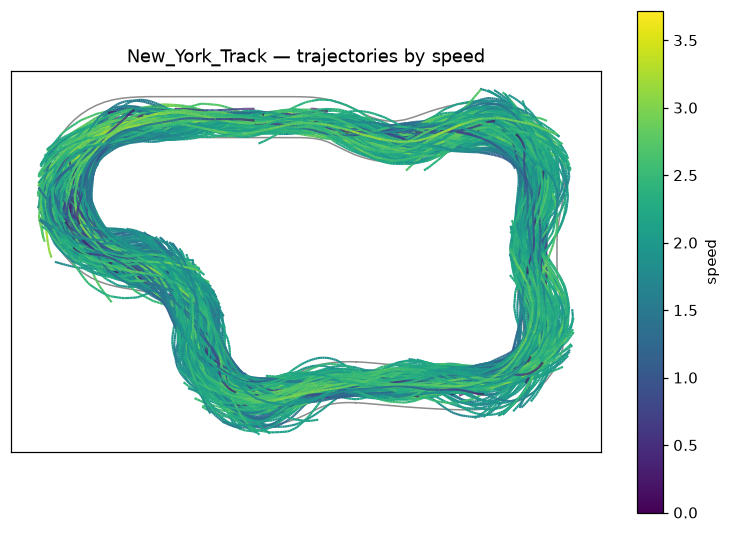

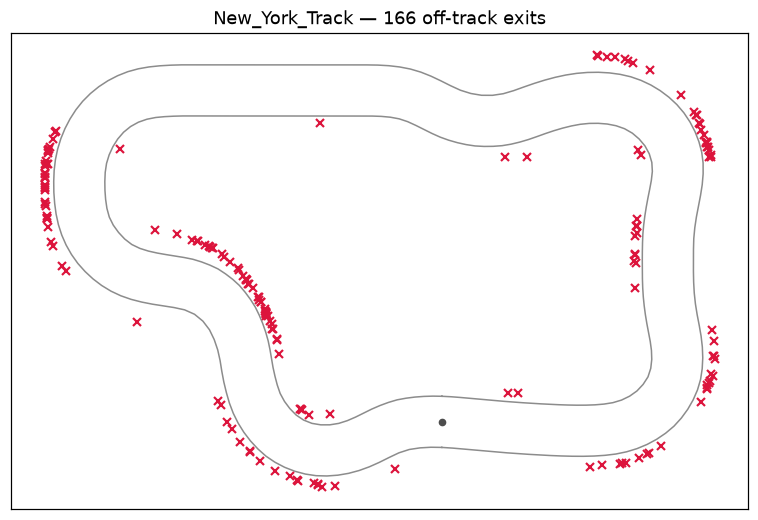

thunder_hill_open: 225 episodes, completion 8.9%, mean progress 21.4 m


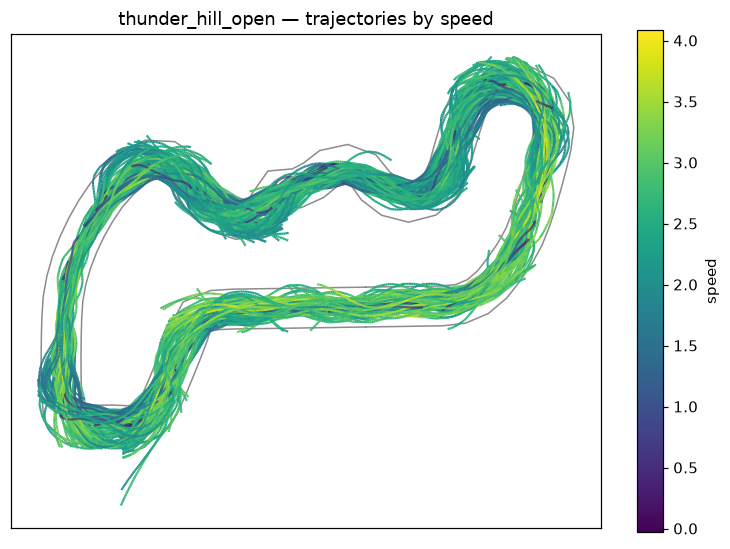

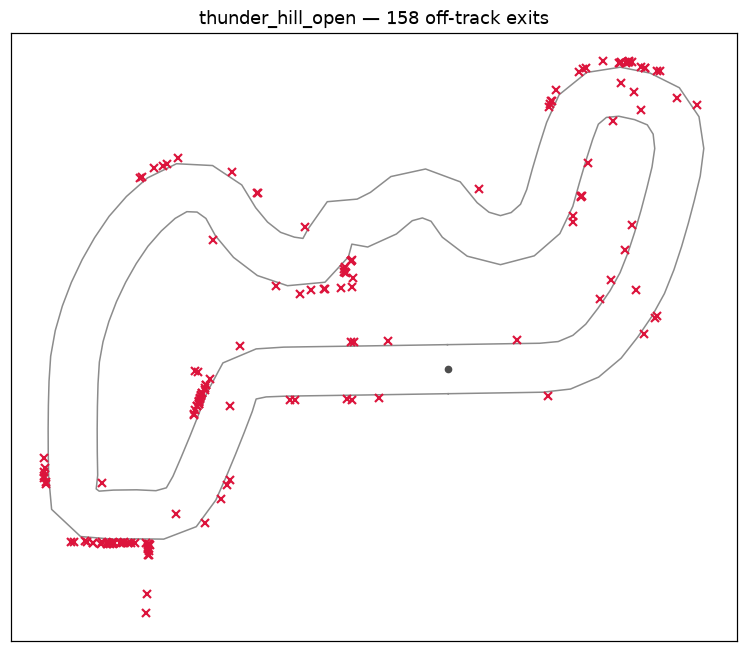

arctic_open: 265 episodes, completion 3.8%, mean progress 18.8 m


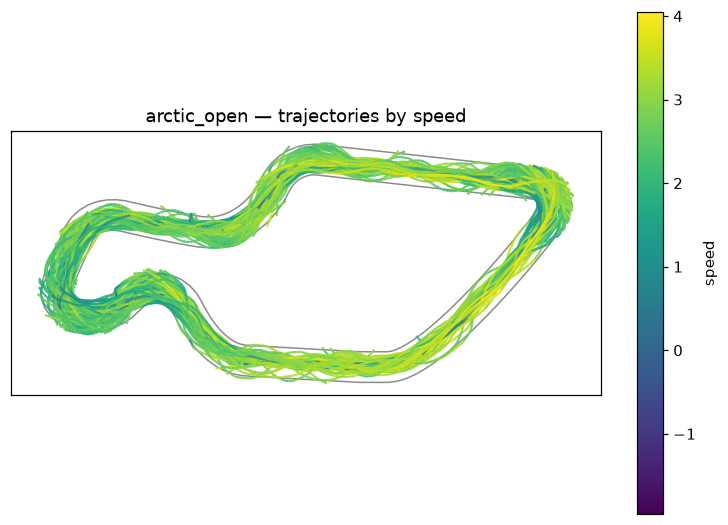

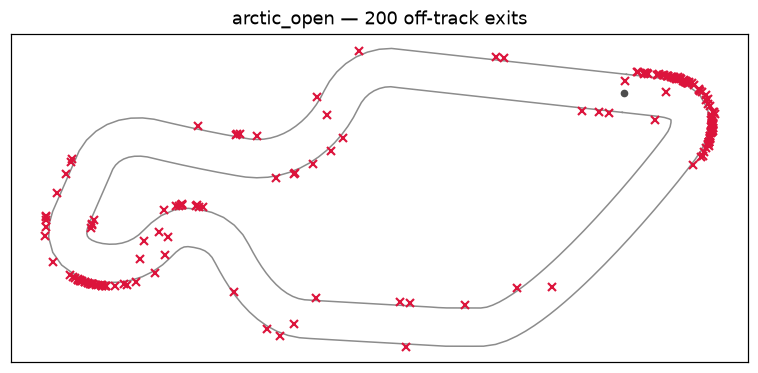

In [9]:
"""Trajectories and off-track exits on every never-seen circuit."""

import os

from deepracer_genesis.analysis.telemetry import episode_agg, load_telemetry
from deepracer_genesis.analysis.trackplots import (plot_offtrack_hotspots,
                                                   plot_trajectories)

for track in HOLDOUT_TRACKS:
    path = os.path.join(RUN_DIR, "telemetry", f"holdout_{track}.parquet")
    if not os.path.exists(path):
        print(f"{track}: no telemetry recorded")
        continue
    hdf = load_telemetry(path)
    agg = episode_agg(hdf)
    print(f"{track}: {len(agg)} episodes, "
          f"completion {agg['completed_lap'].mean():.1%}, "
          f"mean progress {agg['progress_total_m'].mean():.1f} m")
    show_fig(plot_trajectories(hdf, track, color_by="speed"))
    show_fig(plot_offtrack_hotspots(hdf, track))


In [10]:
"""Rollout video on the hardest holdout (cached like every other step)."""

vid = recorded("video")
if vid is None:
    import os

    from deepracer_genesis.experiment import rollout_video
    path = rollout_video(diverse_spec(steps=FINAL_STEPS,
                                      eval_every=EVAL_EVERY,
                                      variant="final", **HPO_BEST),
                         ckpt=os.path.join(RUN_DIR, "model.pt"),
                         track="thunder_hill_open", steps=400, num_envs=8)
    vid = record_result("video", {"video": path})
print(vid)


{'video': 'runs/best_camera_diverse/best_camera_diverse/final-0-f25d6d245c08/videos/spectator_thunder_hill_open.mp4'}


In [11]:
"""The ONNX car bundle — the one step that cannot run in this process.

genesis and onnxruntime bundle clashing LLVM symbols, so the export runs
as a plain CLI call in a fresh process. It needs nothing from this
notebook: the run directory's ``eval_record.json`` + ``model.pt`` are
enough to rebuild and export the actor.
"""

import subprocess
import sys

subprocess.run([sys.executable, "-m", "deepracer_genesis.deploy.onnx",
                RUN_DIR, "--bundle-name", "best_camera_diverse"], check=True)
print(f"car bundle: {RUN_DIR}/export/best_camera_diverse.tar.gz")
print(f"total wall-clock: {elapsed_h():.2f} h")


<frozen runpy>:128: RuntimeWarning: 'deepracer_genesis.deploy.onnx' found in sys.modules after import of package 'deepracer_genesis.deploy', but prior to execution of 'deepracer_genesis.deploy.onnx'; this may result in unpredictable behaviour
<deepracer-genesis>/deepracer_genesis/experiment/spec.py:437: UserWarning: multi-track camera training uses Part O spatial tiling: all 7 track meshes load into every env (render + memory scale ~K); benchmark aggregate steps/sec before scaling the track count
  self._validate_obs_dr()


<deepracer-genesis>/deepracer_genesis/deploy/onnx.py:224: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[export] WARNING: onnxruntime not installed — graph NOT verified against torch. Install the 'export' extra.
[export] policy.onnx + model_card.json + best_camera_diverse.tar.gz -> runs/best_camera_diverse/best_camera_diverse/final-0-f25d6d245c08/export  (onnxruntime missing: NOT verified)


car bundle: runs/best_camera_diverse/best_camera_diverse/final-0-f25d6d245c08/export/best_camera_diverse.tar.gz
total wall-clock: 0.00 h


## Notes

- **Bundle**: `<run_dir>/export/best_camera_diverse.tar.gz` (opset-11 ONNX
  + metadata), same deployment path as round 1.
- **Timeout caveat**: laps on the 40 m holdouts need ≥ ~1.4 m/s inside the
  fixed 30 s episode; compare tracks on mean progress.
- **Reproducibility**: seeded end to end; study resumes from
  `runs/best_camera_diverse/study.db`; step records in
  `runs/best_camera_diverse/logs/`; `REUSE = True` replays them.
